In [ ]:
# @title 1. Kütüphanelerin Kurulumu ve İçe Aktarılması

!pip install transformers datasets evaluate accelerate scikit-learn seaborn matplotlib nltk torch -q

import pandas as pd
import numpy as np
import re
import nltk
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import evaluate

nltk.download("stopwords")
print("Gerekli kütüphaneler kuruldu ve içe aktarıldı.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
Gerekli kütüphaneler kuruldu ve içe aktarıldı.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Veri seti indiriliyor: https://drive.google.com/uc?export=download&id=1RgIS264M7ovdhzgeo_2kiDRH9s3tdleQ
Veri seti başarıyla yüklendi.
Toplam Kayıt Sayısı: 8491
                                                text  label
1  Ürün gayet güzel boyutları  dört kişilik aile ...      1
2                     Ürünü kullandım gayet memnunum      1
3                                        Hızlı kargo      1
4  8 yıl önce lg 42 lm serisi almıştım ve tv den ...      0
5  ürün fena değil ancak gövdenin plastik olması ...      1


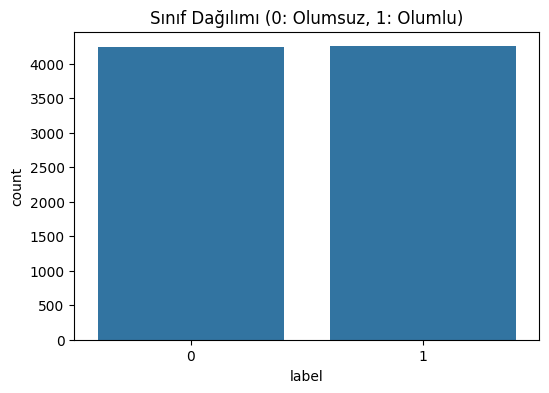

In [ ]:
# @title 2. Veri Yükleme (Google Drive - Herkese Açık Link)


FILE_ID = "1RgIS264M7ovdhzgeo_2kiDRH9s3tdleQ"
DOSYA_URLSI = f"https://drive.google.com/uc?export=download&id={FILE_ID}"

print(f"Veri seti indiriliyor: {DOSYA_URLSI}")

try:
    df = pd.read_csv(DOSYA_URLSI,
                     encoding='utf-16',
                     sep=',',
                     engine='python',
                     header=None,
                     names=['yorum', 'duygu'],
                     on_bad_lines='skip')


    df.columns = ['text', 'label']


    df = df[df['label'].isin(['Olumlu', 'Olumsuz'])]
    df['label'] = df['label'].map({'Olumlu': 1, 'Olumsuz': 0})

    print("Veri seti başarıyla yüklendi.")
    print(f"Toplam Kayıt Sayısı: {len(df)}")
    print(df.head())


    plt.figure(figsize=(6, 4))
    sns.countplot(x='label', data=df)
    plt.title('Sınıf Dağılımı (0: Olumsuz, 1: Olumlu)')
    plt.show()

except Exception as e:
    print(f"Hata oluştu: {e}")

In [ ]:
# @title 3. Veri Ön İşleme

stop_words = set(stopwords.words("turkish"))
stemmer = SnowballStemmer("english")

def on_isleme(metin):

    metin = str(metin).lower()
    metin = re.sub(r'[^a-zA-ZçÇğĞıİöÖşŞüÜ\s]', '', metin)

    kelimeler = metin.split()
    kelimeler = [w for w in kelimeler if w not in stop_words]

    return " ".join(kelimeler)


df['clean_text'] = df['text'].apply(on_isleme)

print("Ön işleme sonrası örnek veri:")
print(df[['text', 'clean_text']].head())


X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['label'], test_size=0.2, random_state=42)


from datasets import Dataset
train_dataset_raw = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
test_dataset_raw = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

Ön işleme sonrası örnek veri:
                                                text  \
1  Ürün gayet güzel boyutları  dört kişilik aile ...   
2                     Ürünü kullandım gayet memnunum   
3                                        Hızlı kargo   
4  8 yıl önce lg 42 lm serisi almıştım ve tv den ...   
5  ürün fena değil ancak gövdenin plastik olması ...   

                                          clean_text  
1  ürün gayet güzel boyutları dört kişilik aile y...  
2                     ürünü kullandım gayet memnunum  
3                                        hızlı kargo  
4  yıl önce lg lm serisi almıştım tv den gayet me...  
5  ürün fena değil ancak gövdenin plastik olması ...  


In [ ]:
# @title 4. Model Eğitimi ve Değerlendirme Altyapısı


accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1);

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    prec = precision_metric.compute(predictions=predictions, references=labels)
    rec = recall_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": prec["precision"],
        "recall": rec["recall"]
    }


def train_transformer_model(model_name, train_ds, test_ds):
    print(f"\n===== {model_name} Modeli Hazırlanıyor =====")


    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    tokenized_train = train_ds.map(tokenize_function, batched=True)
    tokenized_test = test_ds.map(tokenize_function, batched=True)


    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.replace('/', '_')}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        push_to_hub=False,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    print(f"{model_name} eğitiliyor...")
    trainer.train()

    print(f"{model_name} değerlendiriliyor...")
    eval_results = trainer.evaluate()


    predictions = trainer.predict(tokenized_test)
    preds = np.argmax(predictions.predictions, axis=1)

    return eval_results, preds, trainer

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# @title 5. Modellerin Çalıştırılması (BERTurk ve XLM-RoBERTa)

# 1. Model: BERTurk (Türkçe için özel eğitilmiş)
model1_name = "dbmdz/bert-base-turkish-cased"
results_bert, preds_bert, trainer_bert = train_transformer_model(model1_name, train_dataset_raw, test_dataset_raw)

# 2. Model: XLM-RoBERTa (Çok dilli güçlü bir model)
model2_name = "xlm-roberta-base"
results_roberta, preds_roberta, trainer_roberta = train_transformer_model(model2_name, train_dataset_raw, test_dataset_raw)


===== dbmdz/bert-base-turkish-cased Modeli Hazırlanıyor =====


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6792 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3012915612.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


xlm-roberta-base eğitiliyor...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.299897,0.903473,0.900365,0.915946,0.885305


xlm-roberta-base değerlendiriliyor...



--- Model Performans Karşılaştırması ---
         Model  Accuracy        F1  Precision    Recall
0      BERTurk  0.920541  0.917633   0.937656  0.898447
1  XLM-RoBERTa  0.903473  0.900365   0.915946  0.885305


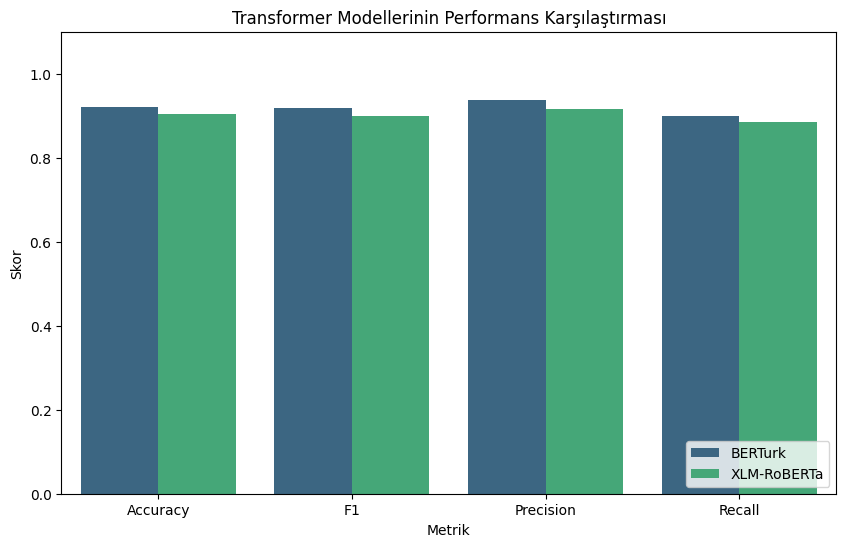

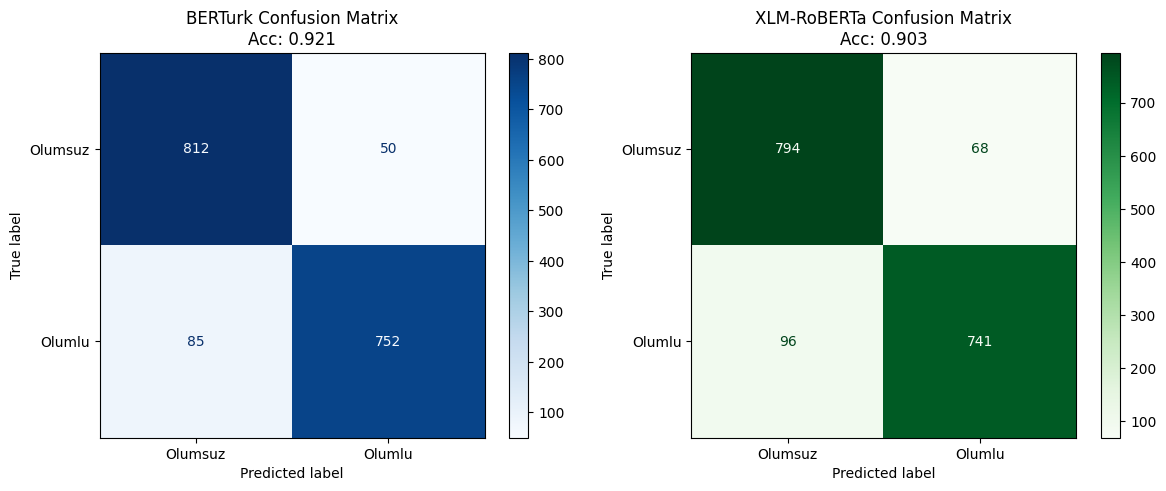

In [ ]:
# @title 6. Sonuçların Görselleştirilmesi ve Raporlama


comparison_df = pd.DataFrame([
    {"Model": "BERTurk", "Accuracy": results_bert['eval_accuracy'], "F1": results_bert['eval_f1'], "Precision": results_bert['eval_precision'], "Recall": results_bert['eval_recall']},
    {"Model": "XLM-RoBERTa", "Accuracy": results_roberta['eval_accuracy'], "F1": results_roberta['eval_f1'], "Precision": results_roberta['eval_precision'], "Recall": results_roberta['eval_recall']}
])

print("\n--- Model Performans Karşılaştırması ---")
print(comparison_df)


df_melted = comparison_df.melt(id_vars="Model", var_name="Metrik", value_name="Skor")

plt.figure(figsize=(10, 6))
sns.barplot(x="Metrik", y="Skor", hue="Model", data=df_melted, palette="viridis")
plt.title("Transformer Modellerinin Performans Karşılaştırması")
plt.ylim(0, 1.1)
plt.ylabel("Skor")
plt.legend(loc='lower right')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


cm_bert = confusion_matrix(y_test, preds_bert)
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=['Olumsuz', 'Olumlu'])
disp_bert.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'BERTurk Confusion Matrix\nAcc: {results_bert["eval_accuracy"]:.3f}')

cm_roberta = confusion_matrix(y_test, preds_roberta)
disp_roberta = ConfusionMatrixDisplay(confusion_matrix=cm_roberta, display_labels=['Olumsuz', 'Olumlu'])
disp_roberta.plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'XLM-RoBERTa Confusion Matrix\nAcc: {results_roberta["eval_accuracy"]:.3f}')

plt.show()

In [ ]:
# @title 7. Gradio Arayüzü ile Tahmin
import gradio as gr
from transformers import pipeline

# En iyi performansı gösteren BERTurk modelini kullanacağız (trainer_bert)
# Modeli Gradio için uygun hale getirmek üzere bir pipeline oluşturuyoruz
# Not: Bu, Trainer nesnesini kullanmak yerine, modeli yükleyip pipeline oluşturmanın daha basit bir yoludur.
# Trainer'ın kendi .predict metodu, Gradio için uygun bir formatta çıktı vermez.

# Eğitilmiş BERTurk modelini yükle
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_for_inference = AutoModelForSequenceClassification.from_pretrained(trainer_bert.args.output_dir + "/checkpoint-425") # En iyi modeli yükle

# Duygu analizi için Transformer Pipeline oluşturma
# Bu, tahmin sürecini basitleştirir.
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model_for_inference,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1  # GPU varsa 0, yoksa -1 (CPU) kullan
)

def predict_sentiment(text):
    """
    Kullanıcıdan alınan metin için duygu tahmini yapar.
    """
    # 1. Metni ön işlemeden geçir:
    clean_text = on_isleme(text)

    # 2. Modeli kullanarak tahmin yap:
    # Model 0: Olumsuz, 1: Olumlu olarak eğitildi.
    result = sentiment_pipeline(clean_text)[0]

    # 3. Sonucu daha okunaklı bir formata dönüştür:
    label_id = int(result['label'].split('_')[-1]) # LABEL_0 veya LABEL_1'den 0 veya 1'i alır

    if label_id == 1:
        sentiment = "Olumlu (Positive) 😊"
    else:
        sentiment = "Olumsuz (Negative) 😞"

    # Tahmin güven skorunu yüzde formatına dönüştürme
    score = result['score'] * 100

    return f"Tahmin: {sentiment}\nGüven Skoru: {score:.2f}%"

custom_css = """
.large-output-text textarea {
    font-size: 1.5em !important;
}
"""

# Gradio Arayüzünü Tanımlama
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Lütfen analiz etmek istediğiniz yorumu buraya girin...", label="Yorum Metni"),
    outputs=gr.Textbox(label="Duygu Analizi Sonucu", elem_classes=["large-output-text"]),
    title="BERTurk ile Türkçe Duygu Analizi",
    description="Eğitilmiş BERTurk modelini kullanarak girdiğiniz metnin duygu durumunu (Olumlu/Olumsuz) tahmin eder.",
    allow_flagging='never',
    css=custom_css,
    examples=examples
)
examples=[
        ["Ürün gerçekten çok kaliteli, bayıldım! Herkese tavsiye ederim."],     # Olumlu Örnek
        ["Kargo çok geç geldi ve paket özensizdi, hiç memnun kalmadım."],      # Olumsuz Örnek
        ["Tam bir fiyat performans ürünü, beklentimi karşıladı."],             # Olumlu Örnek
        ["Beklediğim gibi çıkmadı, kumaşı çok kalitesiz."],                    # Olumsuz Örnek
        ["Satıcı çok ilgiliydi, sorularıma hemen cevap verdi. Teşekkürler."]   # Olumlu Örnek
    ]
# Arayüzü Başlatma
# 'share=True' ile Gradio, arayüze herkesin erişebileceği geçici bir genel link oluşturur.
# Bu link Colab çıktı hücrenizde görünecektir.
print("\n--- Gradio Arayüzü Başlatılıyor ---")
iface.launch(share=True)

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(



--- Gradio Arayüzü Başlatılıyor ---
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://144f8b1799c4f9d8e1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
